In [2]:
"""
Last.fm devulve stats.listeners y stats.playcount por artista
El problema es la ley de las potencias, el 1% de los artistas va a concentrar el 90% de las escuchas

Para que el motor funcione necesita un coeficiente que escale del 0 al 1 o del 0 al 100
Entonces, toca un analisis con un par de datos:
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata, percentileofscore

plt.style.use('ggplot')

In [3]:
N = 6000

raw_listener = (np.random.pareto(1.2, N) + 1) * 50_000 # 50_000 escala los resultados haciendo que el minimo sea de 50000
"""
    El m +1 transforma el valor minimo a 1 por una cuestion de simplicidad matematica.    

    La distribucion de pareto simula una distribucion de ley de potencias
la distribucion de los datoa tambien es de cola larga. La mayoria de los artistas
tienen pocos oyentes, mientras que unos pocos artistas tienen millones.
"""
raw_playcount = raw_listener * (np.random.uniform(20, 500, N)) # Se generan 'N' valores aleatorios entre [20, 500]
"""
    Aca se asume que el total de reproducciones es proporcional al numero de oyentes.
    En los valores reales obtenidos a traves de la API, estos valores explicarian que tan 
'repetitiva' es la audiencia de cada artista.
"""

"\n    Aca se asume que el total de reproducciones es proporcional al numero de oyentes.\n    En los valores reales obtenidos a traves de la API, estos valores explicarian que tan \n'repetitiva' es la audiencia de cada artista.\n"

In [17]:
df = pd.DataFrame({
    'artista': [f"Artista {i}" for i in range(N)],
    'oyentes': raw_listener.astype(int),
    'reproducciones': raw_playcount.astype(int)
})

total = df['oyentes'].sum()
mejores_50 = df.nlargest(50, "oyentes")["oyentes"].sum()

print(f"El top 1% de los artistas concentra el {round((mejores_50/total)*100, 2)}% de los oyentes\n")

# Para ver un poco mejor los valores voy a traer 5 bandas reales, deberia cambiar el valor
"""
    Los artistas que voy a usar son:
    1_ACDC              46.400.000 - 25.600.000.000
    2_Queen             54.600.000 - 28.900.000.000
    3_Rediohead         52.600.000 - 15.900.000.000
    4_The Beatles       35.400.000 - 25.600.000.000
    5_Guns N' Roses   38.400.000 - 13.300.000.000  
"""

raw_listener[:5] = [46.4e6, 54.6e6, 52.6e6, 35.4e6, 38.4e6]
raw_playcount[:5] = [25.6e9, 28.9e9, 15.9e9, 25.6e9, 13.3e9]

df = pd.DataFrame({
    'artista': [f"Artista {i}" for i in range(N)],
    'oyentes': raw_listener.astype(int),
    'reproducciones': raw_playcount.astype(int)
})

df.loc[0, 'artista'] = 'ACDC'
df.loc[1, 'artista'] = 'Queen'
df.loc[2, 'artista'] = 'Radiohead'
df.loc[3, 'artista'] = 'The Beatles'
df.loc[4, 'artista'] = "Guns N' Roses"

total = df['oyentes'].sum()
mejores_50 = df.nlargest(50, "oyentes")["oyentes"].sum()

print("\nNuevos valores:")
print(f"El top 1% de los artistas concentra el {round((mejores_50/total)*100, 2)}% de los oyentes")
# Son mucho mejores valores, pero ya son suficientes para hacer la estimacion del coeficiente.

El top 1% de los artistas concentra el 43.17% de los oyentes


Nuevos valores:
El top 1% de los artistas concentra el 43.17% de los oyentes


Text(0, 0.5, 'Frecuencia')

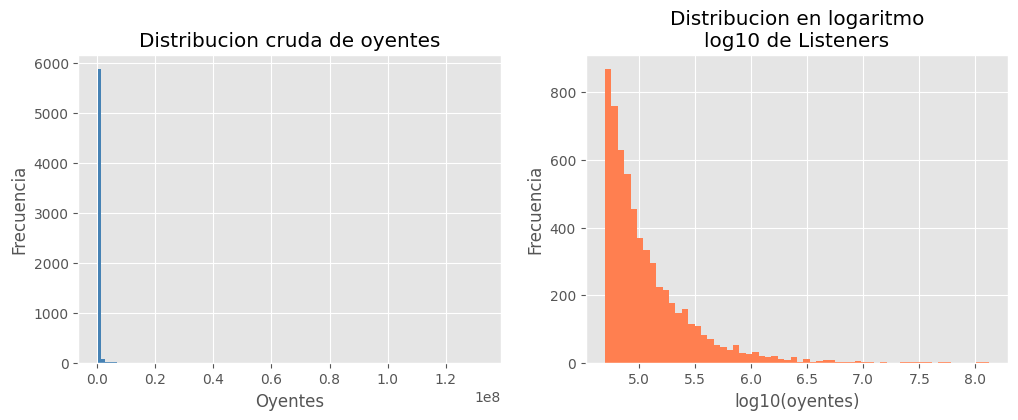

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['oyentes'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribucion cruda de oyentes')
axes[0].set_xlabel('Oyentes') 
axes[0].set_ylabel('Frecuencia')


axes[1].hist(np.log10(df['oyentes'] + 1), bins=60, color='coral', edgecolor='none')
axes[1].set_title('Distribucion en logaritmo\nlog10 de Listeners')
axes[1].set_xlabel('log10(oyentes)')
axes[1].set_ylabel('Frecuencia')


In [29]:
"""
    Para tener un coeficiente se tienen que conseguir valores del 0 al 1 normalizando los valores.
    La formula estandar del normalizado es: 
        Xnormalizada = (x - x.min())/(x.max() - x.min())
"""


def minmax_lineal(x):
    # Normalizacion lineal en minimo y maximo, son los valores bases
    return (x - x.min()) / (x.max() - x.min())


def log_minmax(x, base=10):
    # Normalizacion logaritmica
    # Se comprime la diferencia entre valores chicos y grandes
    log_x = np.log(x + 1) / np.log(base) # La suma de (x + 1) es para evitar el logaritmo de 0
    return (log_x - log_x.min()) / (log_x.max() - log_x.min())


def percentil_rank(x):
    '''
        Para entender esta normalizacion se puede hacer un ejemplo con el siguiente array: [10, 20, 20 30]
    donde se asignarian los rangos 1, 2, 3, y 4, pero como hay dos 20's estos reciben el promedio 
    de sus rangos, 2 y 3, como resultado de los rangos se tendria esto [1, 2.5, 2.5, 4].
    '''
    # Normalizacion por posicion de percentil en el corpus
    return rankdata(x, method='average') / len(x) # Asigna un rango a cada elemento x
    # se divide por el numero total de elementos para obtener la normalizacion.


def log_sigmoide(x, k=15):
    # Normalizacion sigmoidea, tiene mas control sobre la curva.
    log_x = np.log(x + 1) # Transformacion logaritmica, (x + 1) evita errores de logaritmo de 0.
    mu = np.median(log_x) # No usa una media como promedio, usa una mediana porque cambia menos a con
    # respecto a valores extremos.
    sigma = log_x.std() # Desviacion estandar de los datos logaritmicos
    z = k * (log_x - mu) / sigma # Basicamente, ahora los datos tienen centro en 0 y 
    # dispercion pareciada a la desviacion estandar. El factor k es un coeficiente  de suavizado o pendiente.
    return 1 / (1 + np.exp(-z))

In [ ]:
df['idx_lineal'] = minmax_lineal(df['oyentes'].values)
df['idx_logartimico'] = log_minmax(df['oyentes'].values)
df['idx_percentil'] = percentil_rank(df['oyentes'].values)
df['idx_sigmoide'] = log_sigmoide(df['oyentes'].values) 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()